In [121]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, scipy.io as sio

%matplotlib inline
import matplotlib.pyplot as plt, matplotlib.path as mpath
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs, cartopy.feature as cfeature
plt.rcParams['figure.dpi'] = 110

DATA = Path('/Users/advik/Library/Mobile Documents/com~apple~CloudDocs/Documents/'
            'Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium')

N_POTENTIAL, N_EXIST = 5794, 118      # rows 0..5793 potential; 5794..5911 existing
N_SITES = N_POTENTIAL + N_EXIST       # 5912

ENSEMBLE = 'MRE'      # 'MME' (1001 members) | 'MRE' (160)
VARIABLE = 'Temp'     # 'Temp' | 'Accum'

# R derivation. RSheet.csv (== AccumR.mat 'SafeR') is the "accumR" variant and
# reproduces all four BS_* outputs exactly, for BOTH temperature and
# accumulation. "orogR" is the alternative derivation.
#   NOTE: temp*_RComb.csv / temp*_ROrog.csv are RESULT files, not R inputs.
R_MODE = 'accumR'          # 'accumR' | 'orogR'


print('data dir exists:', DATA.exists())


data dir exists: True


In [122]:
# ---------------------------------------------------------------------------
# Loaders: estimates (Ye), metric (J), uncertainties (R)
#
# Layout: rows 0..5793 are the potential sites, 5794..5911 the 118 existing
# proxies (confirmed by run.m's `optimal = 5913 - s` counting down).
# ---------------------------------------------------------------------------

def read_numbers(path):
    """Whitespace/newline-delimited numeric file, skipping any header token."""
    out = []
    for tok in Path(path).read_text().split():
        try: out.append(float(tok))
        except ValueError: pass
    return np.asarray(out, float)


# ---- MRE block correction --------------------------------------------------
N_BLOCKS = 4            # MRE = 4 reanalyses x 40 years, concatenated
DEBLOCK_MRE = True      # False reproduces the raw (uncorrected) MRE runs

def deblock(X, n_blocks=N_BLOCKS):
    """Remove each reanalysis's own mean along the member axis.

    The MRE ensemble concatenates 4 reanalysis products, so its spread mixes
    genuine climate variability with constant offsets between products. For the
    temperature metric that is catastrophic: one block (ERA5) sits ~40 K below
    the others (190.6 K vs 227.9 / 233.3 / 233.5), so >99% of the "variance"
    the optimal sensor constrains is that single offset. Deblocked, the MRE
    temperature metric variance falls from 321.6 to 0.441 K^2 -- in line with
    MME's 0.620 -- and the top-10 site ranking changes almost completely
    (1/10 overlap for temperature, 0/10 for accumulation).

    The four blocks have comparable within-block SDs (0.58-0.78 K), so removing
    the means keeps the interannual signal and discards only the offsets.

    MUST be applied to the metric and the estimates consistently, or their
    covariance is meaningless. Never applied to MME, which has no blocks.
    """
    X = np.asarray(X, float)
    if X.shape[-1] % n_blocks:
        raise ValueError(f'{X.shape[-1]} members not divisible by {n_blocks}')
    return np.concatenate([b - b.mean(-1, keepdims=True)
                           for b in np.split(X, n_blocks, axis=-1)], axis=-1)


# ---- the three optimalSensor inputs ---------------------------------------
def load_Ye(variable=VARIABLE, ensemble=ENSEMBLE):
    """Proxy estimates, (5912 x nMembers)."""
    key = f'{variable}{ensemble}Ye'
    Ye = np.asarray(sio.loadmat(DATA / f'{key}.mat')[key], float)
    assert Ye.shape[0] == N_SITES, Ye.shape
    if ensemble == 'MRE' and DEBLOCK_MRE:
        Ye = deblock(Ye)
    return Ye

def load_metric(variable=VARIABLE, ensemble=ENSEMBLE):
    """The climate metric J, one value per ensemble member.
    MMETemp.mat / MMEAccum.mat / MRETemp.mat / MREAccum.mat, each (1 x nMembers)."""
    key = f'{ensemble}{variable}'
    J = np.asarray(sio.loadmat(DATA / f'{key}.mat')[key], float).ravel()
    if ensemble == 'MRE' and DEBLOCK_MRE:
        J = deblock(J)
    return J

def load_R(mode=R_MODE, clip_negative=True):
    """Observation error variances, one per site (5912).

    'accumR' -> RSheet.csv, identical to AccumR.mat['SafeR']. Verified: gives
                corr 1.000000 / ratio 1.000000 against all four BS_* MATLAB
                outputs, for BOTH temperature and accumulation.
    'orogR'  -> orographyR.csv (5794 potential) + orographyRExist.csv (118).

    NOTE: temp*_RComb.csv / temp*_ROrog.csv are RESULT files, not R inputs.
    """
    if mode == 'accumR':
        R = read_numbers(DATA / 'RSheet.csv')
    elif mode == 'orogR':
        R = np.concatenate([read_numbers(DATA / 'orographyR.csv')[:N_POTENTIAL],
                            read_numbers(DATA / 'orographyRExist.csv')[:N_EXIST]])
    else:
        raise ValueError(f'unknown R mode {mode!r}')

    n_nan = int(np.isnan(R).sum())
    if n_nan:
        print(f'  {n_nan} NaN R values -> 0')
        R = np.nan_to_num(R, nan=0.0)
    if clip_negative and (R < 0).any():
        print(f'  clipped {(R < 0).sum()} negative R values to 0')
        R = np.clip(R, 0, None)
    assert R.size == N_SITES, R.size
    return R


# ---- load and report -------------------------------------------------------
Ye, J, R = load_Ye(), load_metric(), load_R()
assert J.size == Ye.shape[1], (J.size, Ye.shape[1])

nM = Ye.shape[1]
unbias = 1.0 / (nM - 1)
Yvar_all = unbias * ((Ye - Ye.mean(1, keepdims=True)) ** 2).sum(1)
J0var = unbias * ((J - J.mean()) ** 2).sum()

deblocked = (ENSEMBLE == 'MRE' and DEBLOCK_MRE)
print(f'{ENSEMBLE} {VARIABLE}:  Ye {Ye.shape}   J {J.shape}   R {R.shape}')
print(f'  R mode   : {R_MODE}')
print(f'  deblock  : {"ON" if deblocked else "off"}'
      f'{"" if ENSEMBLE == "MRE" else " (MME has no block structure)"}')
print(f'  metric variance      {J0var:.6g}')
print(f'  median Ye variance   {np.median(Yvar_all):.6g}')
print(f'  median R             {np.median(R):.6g}')

ratio = np.median(R[:N_POTENTIAL]) / np.median(Yvar_all[:N_POTENTIAL])
print(f'  median R / Ye var    {ratio:.2f}')
if ratio > 5:
    print(f'  WARNING: R is {ratio:.0f}x the estimate variance, so deltaVar is')
    print(f'           R-dominated and the site ranking is driven almost entirely')
    print(f'           by covariance with the metric. RSheet is scaled for')
    print(f'           accumulation; on temperature the units do not match.')


MRE Temp:  Ye (5912, 160)   J (160,)   R (5912,)
  R mode   : accumR
  deblock  : ON
  metric variance      0.441059
  median Ye variance   0.686698
  median R             123.56
  median R / Ye var    182.54
           R-dominated and the site ranking is driven almost entirely
           by covariance with the metric. RSheet is scaled for
           accumulation; on temperature the units do not match.


In [123]:
# Validates the algorithm against MATLAB. Always uses RAW inputs, because the
# BS_* reference files predate the MRE block correction -- deblocking
# legitimately changes the answer (MRE Temp corr drops to 0.20).
#
# Tolerances are set by the reference files, not by us: they carry 5
# significant digits (e.g. "0.26163"), so ~5e-5 relative is the floor.
_key_ye = f'{VARIABLE}{ENSEMBLE}Ye'
_key_J  = f'{ENSEMBLE}{VARIABLE}'
Ye_raw = np.asarray(sio.loadmat(DATA / f'{_key_ye}.mat')[_key_ye], float)
J_raw  = np.asarray(sio.loadmat(DATA / f'{_key_J}.mat')[_key_J], float).ravel()

tgt = read_numbers(DATA / f'BS_{ENSEMBLE}_{VARIABLE.lower()}_accumR.csv')
dv  = OptimalSensor(J_raw, Ye_raw[:N_POTENTIAL],
                    load_R('accumR')[:N_POTENTIAL]).evaluate()

corr    = np.corrcoef(dv, tgt)[0, 1]
rel_err = np.max(np.abs(dv - tgt) / np.maximum(np.abs(tgt), 1e-30))
print(f'algorithm check (raw inputs):')
print(f'   1 - corr        {1 - corr:.3e}')
print(f'   max rel. error  {rel_err:.3e}   (CSV precision floor ~5e-5)')
assert corr > 1 - 1e-8,  f'correlation {corr} too low'
assert rel_err < 1e-3,   f'max relative error {rel_err} exceeds CSV rounding'
print('matches the MATLAB output to the precision of the reference file')

if ENSEMBLE == 'MRE' and DEBLOCK_MRE:
    dv_db = OptimalSensor(J, Ye[:N_POTENTIAL],
                          load_R('accumR')[:N_POTENTIAL]).evaluate()
    print(f'\ndeblocked vs the same MATLAB target: corr '
          f'{np.corrcoef(dv_db, tgt)[0,1]:.6f}')
    print('  (expected to differ -- the reference predates the block correction)')


algorithm check (raw inputs):
   1 - corr        1.289e-10
   max rel. error  4.894e-05   (CSV precision floor ~5e-5)
matches the MATLAB output to the precision of the reference file

deblocked vs the same MATLAB target: corr 0.204621
  (expected to differ -- the reference predates the block correction)


In [124]:
# CCSM4 (CAM4 finite-volume) grid, generated analytically -- identical to
# reading `lat`/`lon` from the 2.6 GB pr_sfc_Amon_CCSM4 file, but instant.
ccsm_lat = np.linspace(-90, 90, 192)
ccsm_lon = np.arange(288) * 1.25

def build_site_coords():
    """Reproduce FindGridSites.ipynb: first 32 latitude rows, masked to land
    by a regridded ERA5 t2m field (data.nc, 2 MB)."""
    era = xr.open_dataset(DATA / 'data.nc')
    t2m = era[list(era.data_vars)[0]].values
    tempMask = np.roll(t2m, 1800, axis=2)
    latInd = pd.read_csv(DATA / 'latInd.csv').values.ravel().astype(int)

    tempRegrid = np.zeros((32, 3600))
    for i, item in enumerate(latInd):
        tempRegrid[i, :] = tempMask[0, item]
    second = np.zeros((32, 7200))
    for i in range(32):
        second[i, :7198] = np.dstack(
            (tempRegrid[i, :-1],
             tempRegrid[i, :-1] + np.diff(tempRegrid[i]) / 2.0)).ravel()
    regrid = second[:, ::25]

    la, lo = [], []
    for i in range(32):
        for j in range(288):
            if regrid[i, j] > 0:
                la.append(ccsm_lat[i]); lo.append(ccsm_lon[j])
    return np.array(la), np.array(lo)

site_lat, site_lon = build_site_coords()
assert site_lat.size == N_POTENTIAL, site_lat.size
print(f'{site_lat.size} potential sites  (lat {site_lat.min():.1f} to {site_lat.max():.1f})')


5794 potential sites  (lat -90.0 to -62.7)


In [125]:
def variance_reduction(Jdev, Ydev, Rvar, unbias):
    """DASH varianceReduction.m:
         deltaVar = (unbias * (Ydev * Jdev')).^2 ./ (Yvar + Rvar)
    Metric variance constrained by each site ASSIMILATED ALONE."""
    Yvar = unbias * (Ydev ** 2).sum(1)
    return (unbias * (Ydev @ Jdev)) ** 2 / (Yvar + Rvar)

def adjusted_gain(Knum, Kdenom, Rbest):
    """dash.kalman.adjusted, scalar case: Knum * Ksqrt^-1 * (Ksqrt + sqrt(R))^-1"""
    ks = np.sqrt(Kdenom)
    return Knum / ks / (ks + np.sqrt(Rbest))

class OptimalSensor:
    """Port of DASH @optimalSensor (Comboul et al. 2015).

    Needs no observations -- only the metric J, estimates Ye and error
    variances R.

    `dash_estimate_update`: DASH updates Ydev with the SCALAR gain derived from
    Jdev, broadcast across sites, rather than each site's own
    cov(Ydev_i, Ybest). Both your local run.m and the official GitHub version
    do this, so it is the default. Set False for the per-site gain.
    """
    def __init__(self, J, Ye, R, dash_estimate_update=True):
        J = np.asarray(J, float).ravel()
        self.nM = J.size
        self.unbias = 1.0 / (self.nM - 1)
        self.Jmean, self.Jdev = J.mean(), J - J.mean()
        self.Ydev = np.asarray(Ye, float) - np.asarray(Ye, float).mean(1, keepdims=True)
        self.R = np.asarray(R, float).ravel()
        self.dash_estimate_update = dash_estimate_update
        self.J0var = self.metric_variance()

    def metric_variance(self):
        return self.unbias * (self.Jdev ** 2).sum()

    def evaluate(self):
        return variance_reduction(self.Jdev, self.Ydev, self.R, self.unbias)

    def assimilate(self, idx):
        Ybest = self.Ydev[idx].copy(); Rbest = self.R[idx]
        Yvar = self.unbias * (Ybest ** 2).sum()
        Ka = adjusted_gain(self.unbias * (self.Jdev @ Ybest), Yvar + Rbest, Rbest)
        self.Jdev = self.Jdev - Ka * Ybest
        if self.dash_estimate_update:
            self.Ydev = self.Ydev - Ka * Ybest
        else:
            KaY = adjusted_gain(self.unbias * (self.Ydev @ Ybest), Yvar + Rbest, Rbest)
            self.Ydev = self.Ydev - KaY[:, None] * Ybest
        self.Ydev[idx] = np.nan
        return self.metric_variance()

    def run(self, N, exclude=None, verbose=True):
        """Rank -> select best -> update -> remove -> repeat.
        `exclude`: boolean mask of sites never selectable (e.g. ice shelves)."""
        sites, variances = [], []
        for s in range(N):
            dv = self.evaluate()
            dv = np.where(np.isfinite(dv), dv, -np.inf)
            if exclude is not None:
                dv = np.where(exclude, -np.inf, dv)
            for k in sites:
                dv[k] = -np.inf
            best = int(np.argmax(dv))
            v = self.assimilate(best)
            sites.append(best); variances.append(v)
            if verbose:
                print(f'  {s+1:3d}  site {best:5d} '
                      f'({site_lat[best]:7.2f}, {site_lon[best]:7.2f})  '
                      f'var {v:.6g}   cumulative {100*(1-v/self.J0var):5.1f}%')
        return np.array(sites), np.array(variances)

print('OptimalSensor defined')


OptimalSensor defined


In [126]:
from scipy.interpolate import griddata
from scipy.spatial import cKDTree

# Existing proxy sites. PlotVariances.ipynb patches one bad longitude.
_sites = pd.read_csv(DATA / 'Sites.csv', header=None).values.astype(float)
_sites[_sites[:, 1] == 161.64, 1] = -161.64
exist_lat, exist_lon = _sites[:, 0], _sites[:, 1]

def interp_field(values, ngrid=100, distance_threshold=1.0):
    """Interpolate site values onto a regular lon/lat mesh, as PlotVariances does.
    Cells further than `distance_threshold` (lon/lat units) from any site are
    blanked so the field doesn't extrapolate off the ice sheet."""
    v = np.asarray(values, float)
    lon_grid = np.linspace(site_lon.min(), site_lon.max(), ngrid)
    lat_grid = np.linspace(site_lat.min(), site_lat.max(), ngrid)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

    tree = cKDTree(np.column_stack((site_lon, site_lat)))
    d, _ = tree.query(np.column_stack((lon_mesh.ravel(), lat_mesh.ravel())))
    far = d.reshape(lon_mesh.shape) > distance_threshold

    grid = griddata((site_lon, site_lat), v, (lon_mesh, lat_mesh), method='linear')
    grid[far] = np.nan
    return lon_mesh, lat_mesh, grid

def plot_variance_map(values, title=None, top_idx=None, top_size=220,
                      cmap=plt.cm.Greens, vmin=0.0, vmax=1.0, figsize=(11, 11),
                      show_exist=True, cbar_label='constrained variance (normalised)'):
    """Interpolated field + blue existing proxies + optional ranked top-N circles."""
    lon_mesh, lat_mesh, grid = interp_field(values)

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.gridlines()

    pm = ax.pcolormesh(lon_mesh, lat_mesh, grid, zorder=0,
                       transform=ccrs.PlateCarree(), cmap=cmap,
                       vmin=vmin, vmax=vmax)
    if show_exist:
        ax.scatter(exist_lon, exist_lat, c='blue', s=50, linewidth=3, alpha=0.25,
                   zorder=1, transform=ccrs.PlateCarree())
    ax.coastlines()


total metric variance 0.441059
best site 5525 (-69.27, 71.25)
  absolute 0.00889012 = 2.0% of total metric variance


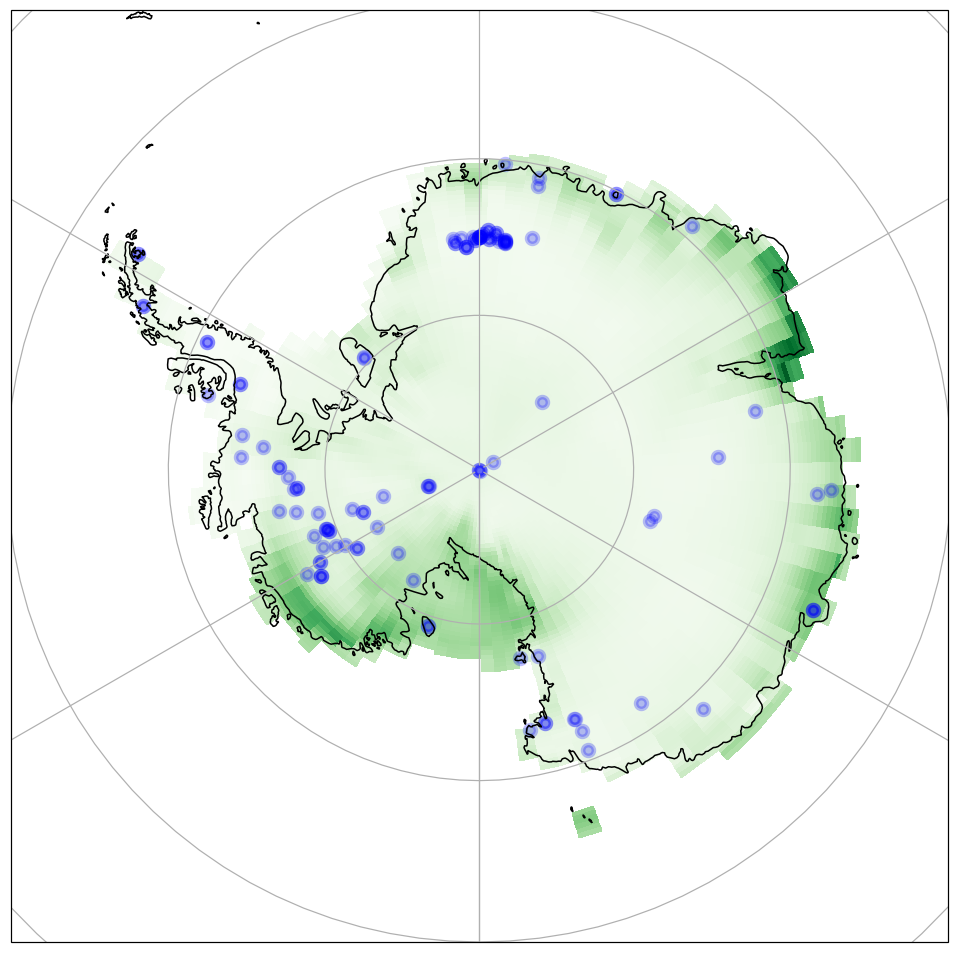

In [127]:
os_blank = OptimalSensor(J, Ye[:N_POTENTIAL], R[:N_POTENTIAL])
dv_blank = os_blank.evaluate()

blank_max = dv_blank.max()
frac_blank = dv_blank / blank_max          # self-normalised, 1.0 = best site

plot_variance_map(frac_blank, title=f'Blank slate — {VARIABLE} {ENSEMBLE}')

k = int(np.argmax(dv_blank))
print(f'total metric variance {os_blank.J0var:.6g}')
print(f'best site {k} ({site_lat[k]:.2f}, {site_lon[k]:.2f})')
print(f'  absolute {dv_blank[k]:.6g} = {100*dv_blank[k]/os_blank.J0var:.1f}% '
      f'of total metric variance')


variance before existing network : 0.441059
variance after  existing network : 0.241573
existing 118 proxies constrain   : 45.2%
best site 5688 (-67.38, 56.25)
  = 1.2% of the variance remaining after the existing network
  augmented best / blank-slate best = 0.334


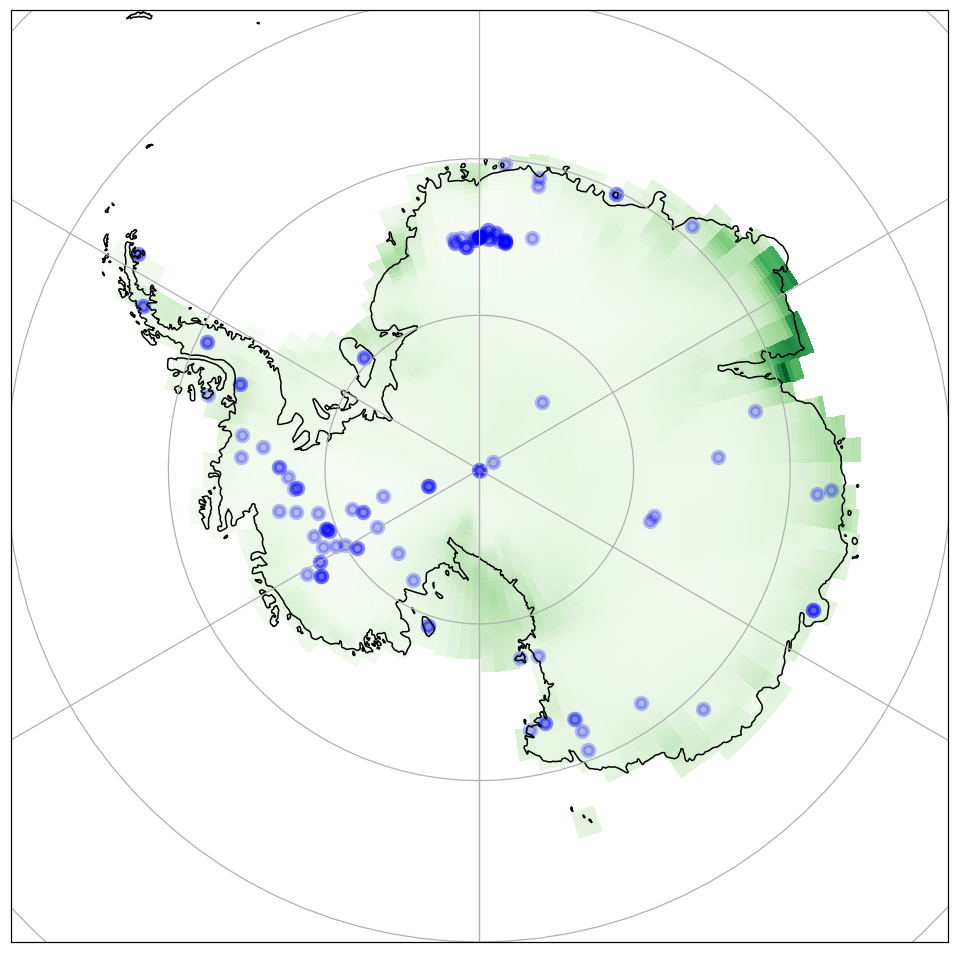

In [128]:
os_aug = OptimalSensor(J, Ye, R)
for idx in range(N_SITES - 1, N_POTENTIAL - 1, -1):    # 5911..5794, as in run.m
    os_aug.assimilate(idx)

v_exist = os_aug.metric_variance()
print(f'variance before existing network : {os_aug.J0var:.6g}')
print(f'variance after  existing network : {v_exist:.6g}')
print(f'existing 118 proxies constrain   : {100*(1-v_exist/os_aug.J0var):.1f}%')

dv_aug = os_aug.evaluate()[:N_POTENTIAL]
aug_max = dv_aug.max()
frac_aug = dv_aug / aug_max                # standalone 0-1

plot_variance_map(frac_aug, title=f'Augmented network — {VARIABLE} {ENSEMBLE}')

ka = int(np.argmax(dv_aug))
print(f'best site {ka} ({site_lat[ka]:.2f}, {site_lon[ka]:.2f})')
print(f'  = {100*dv_aug[ka]/v_exist:.1f}% of the variance remaining after '
      f'the existing network')
print(f'  augmented best / blank-slate best = {aug_max/blank_max:.3f}')


Top 10 sites — blank slate:
    1  site  5525 ( -69.27,   71.25)  var 0.432169   cumulative   2.0%
    2  site  5688 ( -67.38,   56.25)  var 0.423863   cumulative   3.9%
    3  site  5526 ( -69.27,   72.50)  var 0.416326   cumulative   5.6%
    4  site  5620 ( -68.32,   68.75)  var 0.409506   cumulative   7.2%
    5  site  5752 ( -66.44,   55.00)  var 0.403306   cumulative   8.6%
    6  site  5621 ( -68.32,   70.00)  var 0.397435   cumulative   9.9%
    7  site  5524 ( -69.27,   70.00)  var 0.391811   cumulative  11.2%
    8  site  4372 ( -75.86,  220.00)  var 0.386471   cumulative  12.4%
    9  site  5690 ( -67.38,   58.75)  var 0.381543   cumulative  13.5%
   10  site  5523 ( -69.27,   68.75)  var 0.376885   cumulative  14.5%


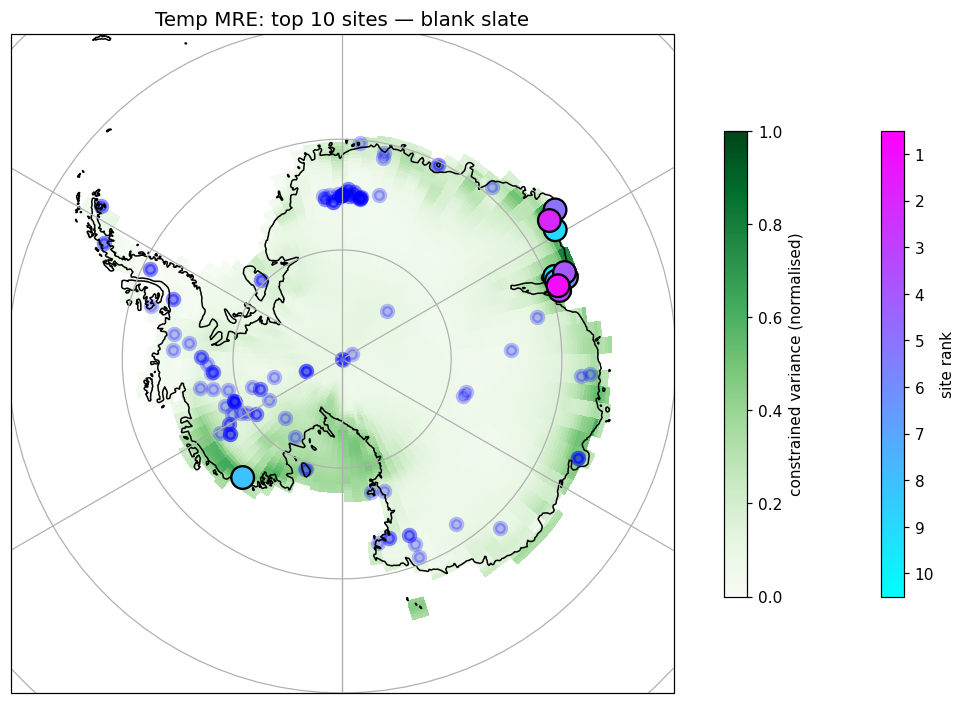

,site,lat,lon,remaining_var,cum_pct
rank,,,,,
1,5525,-69.2670,71.25,0.4322,2.0156
2,5688,-67.3822,56.25,0.4239,3.8987
3,5526,-69.2670,72.50,0.4163,5.6075
4,5620,-68.3246,68.75,0.4095,7.1539
5,5752,-66.4398,55.00,0.4033,8.5595
6,5621,-68.3246,70.00,0.3974,9.8907
7,5524,-69.2670,70.00,0.3918,11.1658
8,4372,-75.8639,220.00,0.3865,12.3766
9,5690,-67.3822,58.75,0.3815,13.4939


In [129]:
N_NEW = 10

os_iter = OptimalSensor(J, Ye[:N_POTENTIAL], R[:N_POTENTIAL])
print(f'Top {N_NEW} sites — blank slate:')
sites_it, var_it = os_iter.run(N_NEW)

def plot_top_sites(field, top_idx, title, top_size=220, cmap_field=plt.cm.Greens):
    """Interpolated field + blue existing proxies + ranked circles (pink=1, cyan=N),
    with separate colorbars for the field and the rank.
    Circles are drawn worst-first so rank 1 ends up on top where they overlap."""
    n = len(top_idx)
    lon_grid = np.linspace(site_lon.min(), site_lon.max(), 100)
    lat_grid = np.linspace(site_lat.min(), site_lat.max(), 100)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    d, _ = cKDTree(np.column_stack((site_lon, site_lat))).query(
        np.column_stack((lon_mesh.ravel(), lat_mesh.ravel())))
    grid = griddata((site_lon, site_lat), field, (lon_mesh, lat_mesh), method='linear')
    grid[d.reshape(lon_mesh.shape) > 1.0] = np.nan

    fig = plt.figure(figsize=(12, 11))
    ax = plt.axes(projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.gridlines()
    pm = ax.pcolormesh(lon_mesh, lat_mesh, grid, zorder=0,
                       transform=ccrs.PlateCarree(), cmap=cmap_field, vmin=0, vmax=1)
    ax.scatter(exist_lon, exist_lat, c='blue', s=50, linewidth=3, alpha=0.25,
               zorder=1, transform=ccrs.PlateCarree())
    ax.coastlines()

    # matplotlib has no per-point zorder within one scatter, so reverse the
    # draw order: rank N is painted first, rank 1 last.
    ranks = np.arange(1, n + 1)
    order = np.arange(n)[::-1]
    sc = ax.scatter(site_lon[top_idx][order], site_lat[top_idx][order],
                    c=ranks[order], s=top_size, linewidth=1.5, edgecolors='black',
                    cmap=plt.cm.cool_r, vmin=0.5, vmax=n + 0.5, zorder=3,
                    transform=ccrs.PlateCarree())

    cb_rank = fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.03, ticks=ranks)
    cb_rank.set_label('site rank')
    cb_rank.ax.invert_yaxis()                    # rank 1 at the top
    cb_field = fig.colorbar(pm, ax=ax, shrink=0.5, pad=0.06)
    cb_field.set_label('constrained variance (normalised)')

    ax.set_title(title, fontsize=13)
    plt.show()
    return fig, ax


plot_top_sites(frac_blank, sites_it,
               f'{VARIABLE} {ENSEMBLE}: top {N_NEW} sites — blank slate')

pd.DataFrame({'rank': np.arange(1, N_NEW+1), 'site': sites_it,
              'lat': site_lat[sites_it], 'lon': site_lon[sites_it],
              'remaining_var': var_it,
              'cum_pct': 100*(1 - var_it/os_iter.J0var)}).set_index('rank').round(4)


Top 10 sites — augmented (after the existing 118):
    1  site  5688 ( -67.38,   56.25)  var 0.2386   cumulative  45.9%
    2  site  5525 ( -69.27,   71.25)  var 0.235809   cumulative  46.5%
    3  site  5526 ( -69.27,   72.50)  var 0.233218   cumulative  47.1%
    4  site  5524 ( -69.27,   70.00)  var 0.231114   cumulative  47.6%
    5  site  5620 ( -68.32,   68.75)  var 0.229097   cumulative  48.1%
    6  site  5752 ( -66.44,   55.00)  var 0.227163   cumulative  48.5%
    7  site  5753 ( -66.44,   56.25)  var 0.225327   cumulative  48.9%
    8  site  5689 ( -67.38,   57.50)  var 0.223582   cumulative  49.3%
    9  site  5621 ( -68.32,   70.00)  var 0.221895   cumulative  49.7%
   10  site  5523 ( -69.27,   68.75)  var 0.220325   cumulative  50.0%


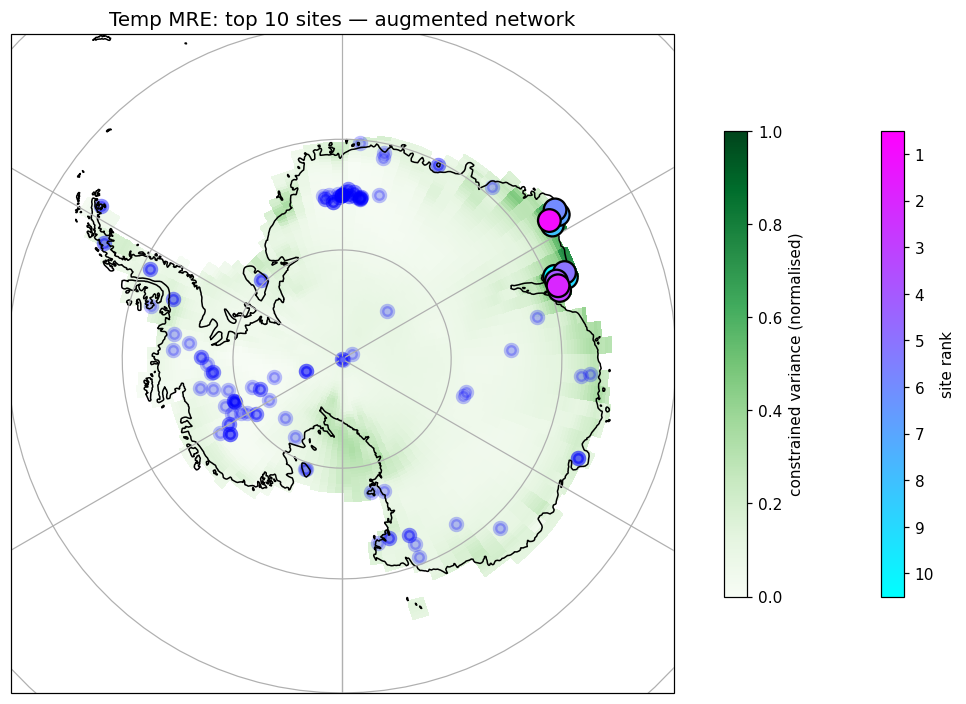


variance after existing 118 : 0.241573 (45.2% of total already constrained)
after 10 more sites      : 0.220325 (50.0% of total)


,site,lat,lon,remaining_var,pct_of_remaining,pct_of_total
rank,,,,,,
1,5688,-67.3822,56.25,0.2386,1.2307,45.9029
2,5525,-69.2670,71.25,0.2358,2.3860,46.5356
3,5526,-69.2670,72.50,0.2332,3.4585,47.1231
4,5524,-69.2670,70.00,0.2311,4.3295,47.6001
5,5620,-68.3246,68.75,0.2291,5.1647,48.0575
6,5752,-66.4398,55.00,0.2272,5.9652,48.4960
7,5753,-66.4398,56.25,0.2253,6.7253,48.9123
8,5689,-67.3822,57.50,0.2236,7.4477,49.3080
9,5621,-68.3246,70.00,0.2219,8.1458,49.6904


In [130]:
N_NEW_AUG = 10

# Fresh object so Cell 7's os_aug isn't mutated by run().
os_aug_iter = OptimalSensor(J, Ye, R)
for idx in range(N_SITES - 1, N_POTENTIAL - 1, -1):    # assimilate the 118 first
    os_aug_iter.assimilate(idx)
v0_aug = os_aug_iter.metric_variance()

print(f'Top {N_NEW_AUG} sites — augmented (after the existing 118):')
sites_aug, var_aug = os_aug_iter.run(N_NEW_AUG)
assert (sites_aug < N_POTENTIAL).all(), 'an existing-proxy index was selected'

plot_top_sites(frac_aug, sites_aug,
               f'{VARIABLE} {ENSEMBLE}: top {N_NEW_AUG} sites — augmented network')

aug_table = pd.DataFrame({
    'rank': np.arange(1, N_NEW_AUG+1), 'site': sites_aug,
    'lat': site_lat[sites_aug], 'lon': site_lon[sites_aug],
    'remaining_var': var_aug,
    'pct_of_remaining': 100*(1 - var_aug/v0_aug),        # vs post-existing baseline
    'pct_of_total':     100*(1 - var_aug/os_aug_iter.J0var),
}).set_index('rank')

print(f'\nvariance after existing 118 : {v0_aug:.6g} '
      f'({100*(1-v0_aug/os_aug_iter.J0var):.1f}% of total already constrained)')
print(f'after {N_NEW_AUG} more sites      : {var_aug[-1]:.6g} '
      f'({aug_table.pct_of_total.iloc[-1]:.1f}% of total)')
aug_table.round(4)
